In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import random
from collections import Counter

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
class CharDataset(Dataset):
    """Character-level dataset for sequence-to-sequence tasks"""

    def __init__(self, text, seq_length=50, input_seq_length=30, target_seq_length=20):
        self.text = text
        self.seq_length = seq_length
        self.input_seq_length = input_seq_length
        self.target_seq_length = target_seq_length

        # Create character mappings
        chars = sorted(list(set(text)))
        self.char2idx = {ch: idx for idx, ch in enumerate(chars)}
        self.idx2char = {idx: ch for idx, ch in enumerate(chars)}
        self.vocab_size = len(chars)

        # Prepare sequences
        self.input_seqs, self.target_seqs = self.create_sequences()

    def create_sequences(self):
        """Create input-output sequence pairs"""
        input_seqs = []
        target_seqs = []

        for i in range(0, len(self.text) - self.seq_length, self.seq_length):
            # Input sequence (first part)
            input_seq = self.text[i:i + self.input_seq_length]
            # Target sequence (next part)
            target_seq = self.text[i + self.input_seq_length:i + self.input_seq_length + self.target_seq_length]

            if len(target_seq) == self.target_seq_length:
                input_seqs.append(self.text_to_indices(input_seq))
                target_seqs.append(self.text_to_indices(target_seq))

        return input_seqs, target_seqs

    def text_to_indices(self, text):
        """Convert text to indices"""
        return [self.char2idx[ch] for ch in text]

    def indices_to_text(self, indices):
        """Convert indices back to text"""
        return ''.join([self.idx2char[idx] for idx in indices])

    def __len__(self):
        return len(self.input_seqs)

    def __getitem__(self, idx):
        return (torch.tensor(self.input_seqs[idx], dtype=torch.long),
                torch.tensor(self.target_seqs[idx], dtype=torch.long))

# Sample text data (you can replace this with your own text)
sample_text = """
The quick brown fox jumps over the lazy dog. Machine learning is fascinating.
Deep learning models can learn complex patterns. Recurrent neural networks are
great for sequence data. Attention mechanisms help focus on important information.
This is a demonstration of sequence to sequence generation using RNN with attention.
"""

# Create dataset
dataset = CharDataset(sample_text, seq_length=50, input_seq_length=30, target_seq_length=20)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

print(f"Vocabulary size: {dataset.vocab_size}")
print(f"Number of sequences: {len(dataset)}")
print(f"Sample input: {dataset.indices_to_text(dataset.input_seqs[0])}")
print(f"Sample target: {dataset.indices_to_text(dataset.target_seqs[0])}")

Vocabulary size: 35
Number of sequences: 6
Sample input: 
The quick brown fox jumps ove
Sample target: r the lazy dog. Mach


In [ ]:
class SimpleSeq2SeqRNN(nn.Module):
    """Basic RNN-based Seq2Seq model without attention"""

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=2):
        super(SimpleSeq2SeqRNN, self).__init__()

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # Encoder RNN
        self.encoder_rnn = nn.GRU(embedding_dim, hidden_dim, num_layers,
                                   batch_first=True, dropout=0.3)

        # Decoder RNN
        self.decoder_rnn = nn.GRU(embedding_dim, hidden_dim, num_layers,
                                   batch_first=True, dropout=0.3)

        # Output layer
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

        self.dropout = nn.Dropout(0.3)

    def forward(self, source, target, teacher_forcing_ratio=0.5):
        batch_size = source.shape[0]
        target_len = target.shape[1]

        # Embed source sequences
        embedded_source = self.dropout(self.embedding(source))

        # Encode source sequence
        encoder_outputs, hidden = self.encoder_rnn(embedded_source)

        # Prepare decoder input (first token is usually start token)
        decoder_input = target[:, 0].unsqueeze(1)  # Use first target token as start

        # Store outputs
        outputs = torch.zeros(batch_size, target_len, self.vocab_size).to(device)

        # Decode sequence
        for t in range(1, target_len):
            # Embed decoder input
            embedded_decoder_input = self.dropout(self.embedding(decoder_input))

            # Decode
            decoder_output, hidden = self.decoder_rnn(embedded_decoder_input, hidden)

            # Get predictions
            prediction = self.fc_out(decoder_output)
            outputs[:, t, :] = prediction.squeeze(1)

            # Teacher forcing
            teacher_force = random.random() < teacher_forcing_ratio
            if teacher_force:
                decoder_input = target[:, t].unsqueeze(1)
            else:
                decoder_input = prediction.argmax(2)

        return outputs

Using device: cpu
Creating dataset...
Vocabulary size: 42
Number of training sequences: 184

Initializing model...
Total trainable parameters: 357,930

TRAINING PHASE
Starting training...
Batch 0/12, Loss: 3.7379
Epoch 1/50, Average Loss: 3.4762
Batch 0/12, Loss: 3.1347
Epoch 2/50, Average Loss: 3.0690
Batch 0/12, Loss: 3.0861
Epoch 3/50, Average Loss: 3.0146
Batch 0/12, Loss: 2.9504
Epoch 4/50, Average Loss: 2.9874
Batch 0/12, Loss: 2.9940
Epoch 5/50, Average Loss: 2.9672
Batch 0/12, Loss: 2.8838
Epoch 6/50, Average Loss: 2.9178
Batch 0/12, Loss: 2.9034
Epoch 7/50, Average Loss: 2.8855
Batch 0/12, Loss: 2.8671
Epoch 8/50, Average Loss: 2.8881
Batch 0/12, Loss: 2.8777
Epoch 9/50, Average Loss: 2.9224
Batch 0/12, Loss: 2.8388
Epoch 10/50, Average Loss: 2.8723
Batch 0/12, Loss: 2.8970
Epoch 11/50, Average Loss: 2.8618
Batch 0/12, Loss: 2.8714
Epoch 12/50, Average Loss: 2.8373
Batch 0/12, Loss: 2.7682
Epoch 13/50, Average Loss: 2.8709
Batch 0/12, Loss: 2.8131
Epoch 14/50, Average Loss: 2.

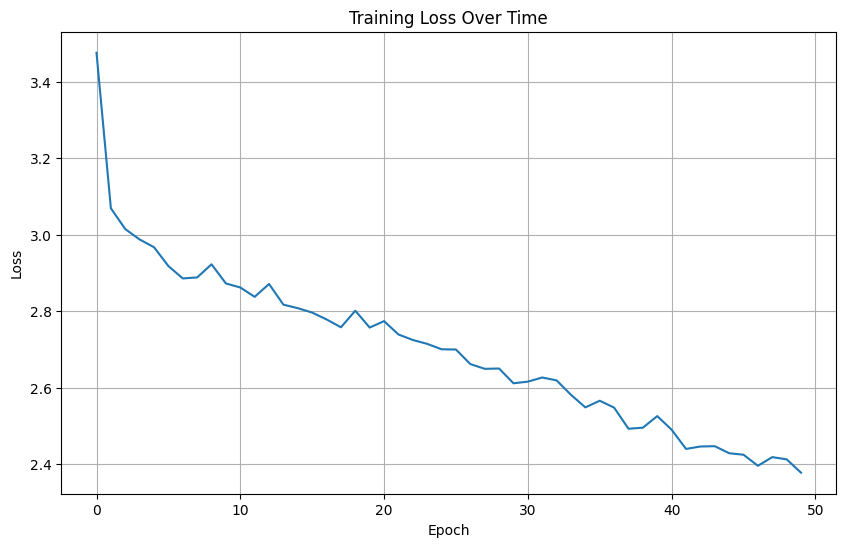


SAMPLE GENERATIONS

Prompt 1: 'The quick brown'
Generated: 'The quick brown  Tee eeee ent  ent  '
--------------------------------------------------

Prompt 2: 'Machine learning'
Generated: 'Machine learnings te tet  te te t   '
--------------------------------------------------

Prompt 3: 'Deep learning models'
Generated: 'Deep learning models  eeel  eee ele  e e'
--------------------------------------------------

Model saved to 'seq2seq_model.pth'

INTERACTIVE TEXT GENERATION
Enter a prompt (or 'quit' to exit):

Prompt: what is important in AI

Generated: what is important in AI th te text  eeeeeee

Prompt: Machine learning

Generated: Machine learnings te tet  te te t   


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random
from collections import Counter
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============= PART 1: DATA PREPARATION =============

class TextDataset(Dataset):
    """Dataset for text generation with start and end tokens"""

    def __init__(self, text, input_length=30, target_length=20, stride=1):
        """
        Args:
            text: String, the training text
            input_length: Length of input sequence
            target_length: Length of target sequence
            stride: How many characters to slide the window
        """
        self.text = text
        self.input_length = input_length
        self.target_length = target_length
        self.stride = stride

        # Create vocabulary with special tokens
        chars = sorted(list(set(text)))
        # Add special tokens
        special_tokens = ['<PAD>', '<START>', '<END>', '<UNK>']
        self.chars = special_tokens + chars

        # Create mappings
        self.char2idx = {ch: idx for idx, ch in enumerate(self.chars)}
        self.idx2char = {idx: ch for idx, ch in enumerate(self.chars)}
        self.vocab_size = len(self.chars)

        # Special token indices
        self.pad_idx = self.char2idx['<PAD>']
        self.start_idx = self.char2idx['<START>']
        self.end_idx = self.char2idx['<END>']
        self.unk_idx = self.char2idx['<UNK>']

        # Prepare sequences
        self.input_seqs, self.target_seqs = self.create_sequences()

    def create_sequences(self):
        """Create sliding window sequences"""
        input_seqs = []
        target_seqs = []

        # Slide window across text
        max_start = len(self.text) - self.input_length - self.target_length

        for i in range(0, max_start + 1, self.stride):
            # Input sequence (no special tokens)
            input_seq = self.text[i:i + self.input_length]

            # Target sequence (add START token at beginning, END at end)
            target_seq = self.text[i + self.input_length:i + self.input_length + self.target_length]

            if len(target_seq) == self.target_length:
                # Convert to indices
                input_indices = self.text_to_indices(input_seq)
                # Add START token to beginning of target
                target_indices = [self.start_idx] + self.text_to_indices(target_seq) + [self.end_idx]

                input_seqs.append(input_indices)
                target_seqs.append(target_indices)

        return input_seqs, target_seqs

    def text_to_indices(self, text):
        """Convert text to indices with unknown token handling"""
        indices = []
        for ch in text:
            if ch in self.char2idx:
                indices.append(self.char2idx[ch])
            else:
                indices.append(self.unk_idx)
        return indices

    def indices_to_text(self, indices):
        """Convert indices back to text"""
        text = []
        for idx in indices:
            if idx not in [self.pad_idx, self.start_idx, self.end_idx]:
                text.append(self.idx2char[idx])
        return ''.join(text)

    def __len__(self):
        return len(self.input_seqs)

    def __getitem__(self, idx):
        return (torch.tensor(self.input_seqs[idx], dtype=torch.long),
                torch.tensor(self.target_seqs[idx], dtype=torch.long))

# ============= PART 2: ENCODER =============

class Encoder(nn.Module):
    """RNN Encoder - reads input sequence and creates context vector"""

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=2, dropout=0.3):
        super(Encoder, self).__init__()

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Embedding layer: converts word indices to dense vectors
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # GRU layer: processes sequence and maintains hidden state
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        """
        Args:
            src: Input sequence (batch_size, src_len)
        Returns:
            hidden: Final hidden state (num_layers, batch_size, hidden_dim)
        """
        # Embed the input sequence
        embedded = self.dropout(self.embedding(src))  # (batch, src_len, embedding_dim)

        # Pass through GRU
        outputs, hidden = self.gru(embedded)  # hidden: (num_layers, batch, hidden_dim)

        return hidden

# ============= PART 3: DECODER =============

class Decoder(nn.Module):
    """RNN Decoder - generates output sequence from context vector"""

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=2, dropout=0.3):
        super(Decoder, self).__init__()

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # GRU layer
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Output layer: converts hidden state to vocabulary probabilities
        self.fc_out = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden):
        """
        Args:
            input: Input token (batch_size, 1)
            hidden: Hidden state from encoder/previous decoder step
        Returns:
            predictions: Output probabilities (batch_size, 1, vocab_size)
            hidden: Updated hidden state
        """
        # Embed input
        embedded = self.dropout(self.embedding(input))  # (batch, 1, embedding_dim)

        # Pass through GRU
        output, hidden = self.gru(embedded, hidden)  # output: (batch, 1, hidden_dim)

        # Generate predictions
        predictions = self.fc_out(output)  # (batch, 1, vocab_size)

        return predictions, hidden

# ============= PART 4: COMPLETE SEQ2SEQ MODEL =============

class Seq2Seq(nn.Module):
    """Complete Sequence-to-Sequence model"""

    def __init__(self, encoder, decoder, device):
        super(Seq2Seq, self).__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, source, target, teacher_forcing_ratio=0.5):
        """
        Args:
            source: Input sequence (batch_size, src_len)
            target: Target sequence (batch_size, trg_len)
            teacher_forcing_ratio: Probability of using teacher forcing
        Returns:
            outputs: Model predictions (batch_size, trg_len, vocab_size)
        """
        batch_size = source.shape[0]
        trg_len = target.shape[1]
        trg_vocab_size = self.decoder.vocab_size

        # Storage for outputs
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)

        # Encode source sequence
        hidden = self.encoder(source)

        # First input is <START> token
        input = target[:, 0].unsqueeze(1)  # (batch_size, 1)

        # Decode step by step
        for t in range(1, trg_len):
            # Get prediction from decoder
            output, hidden = self.decoder(input, hidden)

            # Store prediction
            outputs[:, t, :] = output.squeeze(1)

            # Decide whether to use teacher forcing
            teacher_force = random.random() < teacher_forcing_ratio

            # Get predicted token
            top1 = output.argmax(2)  # (batch_size, 1)

            # Set next input (teacher forcing or predicted)
            if teacher_force:
                input = target[:, t].unsqueeze(1)  # Use ground truth
            else:
                input = top1  # Use model's prediction

        return outputs

    def generate(self, source, max_length=50, start_token=1, end_token=2):
        """
        Generate text from source sequence (inference mode)

        Args:
            source: Input sequence (batch_size, src_len) or (src_len,)
            max_length: Maximum length to generate
            start_token: Index of <START> token
            end_token: Index of <END> token
        Returns:
            generated: List of generated token indices
        """
        self.eval()

        # Handle different input formats
        if len(source.shape) == 1:
            source = source.unsqueeze(0)  # Add batch dimension

        batch_size = source.shape[0]

        with torch.no_grad():
            # Encode source
            hidden = self.encoder(source.to(self.device))

            # Start with <START> token
            input = torch.tensor([[start_token]] * batch_size).to(self.device)

            generated = []

            for _ in range(max_length):
                # Decode
                output, hidden = self.decoder(input, hidden)

                # Get prediction
                predicted_token = output.argmax(2).item()
                generated.append(predicted_token)

                # Stop if end token generated
                if predicted_token == end_token:
                    break

                # Prepare for next step
                input = torch.tensor([[predicted_token]]).to(self.device)

        return generated

# ============= PART 5: TRAINING FUNCTIONS =============

def train_epoch(model, dataloader, optimizer, criterion, device, teacher_forcing_ratio=0.5):
    """Train for one epoch"""
    model.train()
    total_loss = 0

    for batch_idx, (src, trg) in enumerate(dataloader):
        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        # Forward pass
        output = model(src, trg, teacher_forcing_ratio)

        # Reshape output and target for loss calculation
        # output: (batch_size, trg_len, vocab_size)
        # trg: (batch_size, trg_len)
        output_dim = output.shape[-1]
        output = output[:, 1:, :].reshape(-1, output_dim)  # Skip <START> token
        trg = trg[:, 1:].reshape(-1)  # Skip <START> token

        # Calculate loss
        loss = criterion(output, trg)

        # Backward pass
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        total_loss += loss.item()

        # Print progress
        if batch_idx % 100 == 0:
            print(f'Batch {batch_idx}/{len(dataloader)}, Loss: {loss.item():.4f}')

    avg_loss = total_loss / len(dataloader)
    return avg_loss

def train_model(model, dataloader, epochs, learning_rate=0.001, teacher_forcing_ratio=0.5):
    """Complete training loop"""

    # Optimizer
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Loss function (ignore padding index)
    criterion = nn.CrossEntropyLoss(ignore_index=0)

    # Track losses
    losses = []

    print("Starting training...")
    for epoch in range(epochs):
        loss = train_epoch(model, dataloader, optimizer, criterion, device, teacher_forcing_ratio)
        losses.append(loss)
        print(f'Epoch {epoch+1}/{epochs}, Average Loss: {loss:.4f}')

        # Decrease teacher forcing ratio as training progresses
        teacher_forcing_ratio = max(0.3, teacher_forcing_ratio * 0.95)

    return losses

# ============= PART 6: TEXT GENERATION =============

def generate_text(model, dataset, prompt, max_length=100):
    """Generate text continuation from a prompt"""
    model.eval()

    # Convert prompt to indices
    prompt_indices = dataset.text_to_indices(prompt)

    # Ensure prompt length matches training input length
    if len(prompt_indices) > dataset.input_length:
        prompt_indices = prompt_indices[:dataset.input_length]
    elif len(prompt_indices) < dataset.input_length:
        # Pad with zeros if too short
        prompt_indices = prompt_indices + [0] * (dataset.input_length - len(prompt_indices))

    # Convert to tensor
    src_tensor = torch.tensor([prompt_indices]).to(device)

    # Generate continuation
    generated_indices = model.generate(
        src_tensor,
        max_length=max_length,
        start_token=dataset.start_idx,
        end_token=dataset.end_idx
    )

    # Convert back to text
    generated_text = dataset.indices_to_text(generated_indices)

    return prompt + generated_text

# ============= PART 7: VISUALIZATION =============

def plot_training_loss(losses):
    """Plot training loss curve"""
    plt.figure(figsize=(10, 6))
    plt.plot(losses)
    plt.title('Training Loss Over Time')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()

def print_sample_generations(model, dataset, prompts, num_samples=3):
    """Generate and print samples for different prompts"""
    print("\n" + "="*50)
    print("SAMPLE GENERATIONS")
    print("="*50)

    for i, prompt in enumerate(prompts[:num_samples]):
        print(f"\nPrompt {i+1}: '{prompt}'")
        generated = generate_text(model, dataset, prompt, max_length=100)
        print(f"Generated: '{generated}'")
        print("-"*50)

# ============= PART 8: MAIN EXECUTION =============

def main():
    """Main execution function"""

    # Sample training text (you can replace with any text file)
    training_text = """
    The quick brown fox jumps over the lazy dog. This sentence contains every letter of the alphabet.
    Machine learning is a fascinating field that enables computers to learn from data without being explicitly programmed.
    Deep learning models, especially recurrent neural networks, are excellent at processing sequential data like text.
    The attention mechanism allows models to focus on important parts of the input when generating output.
    Sequence to sequence models have revolutionized machine translation, text summarization, and chatbots.
    Training such models requires large amounts of text data and computational resources.
    However, even small models can learn interesting patterns from modest amounts of text.
    The key is to understand the architecture and how information flows through the network.
    This implementation demonstrates a basic RNN-based encoder-decoder for text generation.
    With proper training, the model can learn to continue text in a coherent manner.
    """

    # Remove extra whitespace
    training_text = ' '.join(training_text.split())

    print("Creating dataset...")
    # Create dataset
    dataset = TextDataset(
        text=training_text,
        input_length=30,    # Look at 30 characters
        target_length=20,   # Predict next 20 characters
        stride=5            # Slide window by 5 characters
    )

    print(f"Vocabulary size: {dataset.vocab_size}")
    print(f"Number of training sequences: {len(dataset)}")

    # Create dataloader
    dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

    # Initialize model
    print("\nInitializing model...")
    encoder = Encoder(
        vocab_size=dataset.vocab_size,
        embedding_dim=64,
        hidden_dim=128,
        num_layers=2,
        dropout=0.3
    )

    decoder = Decoder(
        vocab_size=dataset.vocab_size,
        embedding_dim=64,
        hidden_dim=128,
        num_layers=2,
        dropout=0.3
    )

    model = Seq2Seq(encoder, decoder, device).to(device)

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total trainable parameters: {total_params:,}")

    # Train model
    print("\n" + "="*50)
    print("TRAINING PHASE")
    print("="*50)

    losses = train_model(
        model=model,
        dataloader=dataloader,
        epochs=50,
        learning_rate=0.001,
        teacher_forcing_ratio=0.5
    )

    # Plot training loss
    plot_training_loss(losses)

    # Generate text samples
    prompts = [
        "The quick brown",
        "Machine learning",
        "Deep learning models",
        "The attention mechanism",
        "Sequence to sequence"
    ]

    print_sample_generations(model, dataset, prompts)

    # Save model
    torch.save({
        'model_state_dict': model.state_dict(),
        'vocab': dataset.chars,
        'char2idx': dataset.char2idx,
        'idx2char': dataset.idx2char,
        'input_length': dataset.input_length,
        'target_length': dataset.target_length
    }, 'seq2seq_model.pth')

    print("\nModel saved to 'seq2seq_model.pth'")

    return model, dataset

# ============= PART 9: MODEL LOADING AND INFERENCE =============

def load_model(model_path, device):
    """Load a trained model"""
    checkpoint = torch.load(model_path, map_location=device)

    # Recreate dataset structure for vocabulary
    class DummyDataset:
        pass

    dataset = DummyDataset()
    dataset.chars = checkpoint['vocab']
    dataset.char2idx = checkpoint['char2idx']
    dataset.idx2char = checkpoint['idx2char']
    dataset.vocab_size = len(dataset.chars)
    dataset.input_length = checkpoint['input_length']
    dataset.target_length = checkpoint['target_length']
    dataset.start_idx = dataset.char2idx['<START>']
    dataset.end_idx = dataset.char2idx['<END>']
    dataset.pad_idx = dataset.char2idx['<PAD>']
    dataset.unk_idx = dataset.char2idx['<UNK>']

    # Create model
    encoder = Encoder(
        vocab_size=dataset.vocab_size,
        embedding_dim=64,
        hidden_dim=128,
        num_layers=2,
        dropout=0.3
    )

    decoder = Decoder(
        vocab_size=dataset.vocab_size,
        embedding_dim=64,
        hidden_dim=128,
        num_layers=2,
        dropout=0.3
    )

    model = Seq2Seq(encoder, decoder, device).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])

    # Add dataset to model for easy generation
    model.dataset = dataset

    return model, dataset

def interactive_generation(model, dataset):
    """Interactive text generation"""
    print("\n" + "="*50)
    print("INTERACTIVE TEXT GENERATION")
    print("="*50)
    print("Enter a prompt (or 'quit' to exit):")

    while True:
        prompt = input("\nPrompt: ")
        if prompt.lower() == 'quit':
            break

        if len(prompt) < 5:
            print("Please enter a longer prompt (at least 5 characters)")
            continue

        generated = generate_text(model, dataset, prompt, max_length=150)
        print(f"\nGenerated: {generated}")

# ============= RUN THE CODE =============

if __name__ == "__main__":
    # Train a new model
    model, dataset = main()

    # Or load a pre-trained model
    # model, dataset = load_model('seq2seq_model.pth', device)

    # Interactive generation
    interactive_generation(model, dataset)

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Fix random seed so the toy weights stay consistent
torch.manual_seed(42)

# --- CONFIGURATION ---
vocab_size = 6          # [PAD, The, cat, sat, on, mat]
seq_len = 3             # "The cat sat" (length 3)
d_model = 4             # Size of our word vectors (embedding dimension)
d_ff = 16               # Hidden size of Feed-Forward network

print("--- STEP 1: TOKENIZATION ---")
# "The cat sat" mapped to IDs from our vocabulary
input_tokens = torch.tensor([1, 2, 3])
print(f"Tokens tensor: {input_tokens} | Shape: {input_tokens.shape}\n")


print("--- STEP 2: EMBEDDINGS & POSITIONS ---")
# Word lookup table
token_embedding = nn.Embedding(vocab_size, d_model)
print(f"Token Embeeding: {token_embedding}")
# Position lookup table (0, 1, 2 for our 3 positions)
position_embedding = nn.Embedding(seq_len, d_model)

positions = torch.arange(0, seq_len) # [0, 1, 2]
X = token_embedding(input_tokens) + position_embedding(positions)
print(f"Contextualized Vector Matrix X:\n{X}\nShape: {X.shape} (3 tokens, each 4 numbers long)\n")


print("--- STEP 3: SELF-ATTENTION MECHANISM ---")
# Projecting X into Query, Key, and Value matrices
W_q = nn.Linear(d_model, d_model, bias=False)
W_k = nn.Linear(d_model, d_model, bias=False)
W_v = nn.Linear(d_model, d_model, bias=False)

Q = W_q(X)
K = W_k(X)
V = W_v(X)

# 1. Raw Attention Scores (Q multiplied by transpose of K)
# We divide by sqrt(d_model) to keep gradients stable (Scaled Dot-Product)
attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / (d_model ** 0.5)
print(f"Raw Attention Scores (Before Mask):\n{attn_scores}")

# 2. Applying the Mask (The Blindfold)
# Create a lower-triangular matrix of 1s and 0s
mask = torch.tril(torch.ones(seq_len, seq_len))
# Wherever the mask is 0, replace the score with -inf (negative infinity)
attn_scores = attn_scores.masked_fill(mask == 0, float('-inf'))
print(f"\nMasked Attention Scores:\n{attn_scores}")

# 3. Convert scores to percentages (rows add up to 1.0)
# -inf mathematically turns into a clean 0.0% probability here
attn_probs = F.softmax(attn_scores, dim=-1)
print(f"\nAttention Weights (Percentages):\n{attn_probs}")

# 4. Multiply weights by Values to get context-mixed vectors
context_vectors = torch.matmul(attn_probs, V)
print(f"\nContext Vectors Shape: {context_vectors.shape}\n")


print("--- STEP 4: FEED-FORWARD NETWORK (FFN) ---")
# Process vectors individually to inject world-knowledge/facts
ffn = nn.Sequential(
    nn.Linear(d_model, d_ff),
    nn.ReLU(),
    nn.Linear(d_ff, d_model)
)
ffn_output = ffn(context_vectors)
print(f"FFN Output Shape: {ffn_output.shape}\n")


print("--- STEP 5: OUTPUT PROJECTION (LM HEAD) ---")
# Project our final d_model vectors back out to vocabulary size
lm_head = nn.Linear(d_model, vocab_size)

# We ONLY look at the very last vector (index -1, representing "sat")
# because it holds the context of everything before it.
next_token_logits = lm_head(ffn_output[-1, :])
print(f"Raw Logits for next token: {next_token_logits.detach()}")

# Turn raw numbers into clean probabilities
next_token_probs = F.softmax(next_token_logits, dim=-1)

print("\n--- FINAL PREDICTION PROBABILITIES ---")
vocab_words = ["[PAD]", "The", "cat", "sat", "on", "mat"]
for word, prob in zip(vocab_words, next_token_probs):
    print(f"{word:<7}: {prob.item()*100:.2f}%")

# Select the token ID with the highest probability
predicted_id = torch.argmax(next_token_probs).item()
print(f"\nPredicted Next Token ID: {predicted_id} ('{vocab_words[predicted_id]}')")

--- STEP 1: TOKENIZATION ---
Tokens tensor: tensor([1, 2, 3]) | Shape: torch.Size([3])

--- STEP 2: EMBEDDINGS & POSITIONS ---
Token Embeeding: Embedding(6, 4)
Contextualized Vector Matrix X:
tensor([[ 2.0310, -0.5482, -0.3708, -0.8097],
        [ 0.6374, -0.6305,  0.0294,  0.0031],
        [-1.1608,  0.6179, -2.3254,  0.5123]], grad_fn=<AddBackward0>)
Shape: torch.Size([3, 4]) (3 tokens, each 4 numbers long)

--- STEP 3: SELF-ATTENTION MECHANISM ---
Raw Attention Scores (Before Mask):
tensor([[-1.3066, -0.2845,  0.0595],
        [-0.2942, -0.0574, -0.1374],
        [-0.0874, -0.1723,  1.0380]], grad_fn=<DivBackward0>)

Masked Attention Scores:
tensor([[-1.3066,    -inf,    -inf],
        [-0.2942, -0.0574,    -inf],
        [-0.0874, -0.1723,  1.0380]], grad_fn=<MaskedFillBackward0>)

Attention Weights (Percentages):
tensor([[1.0000, 0.0000, 0.0000],
        [0.4411, 0.5589, 0.0000],
        [0.2000, 0.1837, 0.6163]], grad_fn=<SoftmaxBackward0>)

Context Vectors Shape: torch.Size([3, 